# Week 9 Phase 1.19B — prospective robust monotone pool LSE

This notebook reads the frozen prospective artifacts. Structural inferences are provisional and every error is counted.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
OUT=Path('../../outputs/week9_phase1_19b_prospective_robust_monotone_pool_lse')
assert OUT.exists()
print('Artifact root:',OUT.resolve())

Artifact root: C:\Users\ozgur\Documents\thesis-week9-phase1-19a-integrity-posterior-monotonicity-audit\outputs\week9_phase1_19b_prospective_robust_monotone_pool_lse


## 1. Frozen gate and protocol

The 22,050 comparable pairs and three violations must reproduce before prospective work. Twenty feature-only maximin designs are shared across arms.

In [2]:
display(json.loads((OUT/'baseline_gate.json').read_text()))
display(pd.read_csv(OUT/'run_specification.csv').head(8))

{'branch': 'codex/week9-phase1-19b-prospective-robust-monotone-pool-lse',
 'conduction': 332,
 'independent_reproduction': [{'N': 405,
   'directed_pairs': 22050,
   'population': 'full_405',
   'violations': 3},
  {'N': 364,
   'directed_pairs': 19491,
   'population': 'main_364',
   'violations': 3}],
 'keyholes': 73,
 'merge_base': '2975e72326f1680e81f16e0a29fc003bcaaf2aae',
 'parent_sha': '2975e72326f1680e81f16e0a29fc003bcaaf2aae',
 'phase19a_artifact_values': {'full_pairs': 22050,
  'full_violations': 3,
  'main_pairs': 19491,
  'main_violations': 3},
 'population': 405,
 'status': 'PASS'}

,population,repeat,arm,initial_design,initial_design_N,max_budget,feature_only
0,full_405,1,P0_M3_MARGIN_STANDARD,20;153;144;398;157;69;147;177;33;111;314;18;24...,16,120,True
1,full_405,1,P1_M3_MARGIN_MONO,20;153;144;398;157;69;147;177;33;111;314;18;24...,16,120,True
2,full_405,1,P2_MONO_BISECTION_M3,20;153;144;398;157;69;147;177;33;111;314;18;24...,16,120,True
3,full_405,1,P3_MONO_EXPECTED_GAIN_M3,20;153;144;398;157;69;147;177;33;111;314;18;24...,16,120,True
4,full_405,2,P0_M3_MARGIN_STANDARD,300;136;183;308;157;398;313;147;69;144;326;177...,16,120,True
5,full_405,2,P1_M3_MARGIN_MONO,300;136;183;308;157;398;313;147;69;144;326;177...,16,120,True
6,full_405,2,P2_MONO_BISECTION_M3,300;136;183;308;157;398;313;147;69;144;326;177...,16,120,True
7,full_405,2,P3_MONO_EXPECTED_GAIN_M3,300;136;183;308;157;398;313;147;69;144;326;177...,16,120,True


## 2. Four prospective arms

P0 is ordinary M3 margin. P1 removes conflict-free inferred points. P2 maximizes worst-case poset gain. P3 combines frozen M3 uncertainty and normalized expected structural gain. Inferred labels never train M3.

mean       std
population arm                                         
full_405   P0_M3_MARGIN_STANDARD     0.984890  0.003170
           P1_M3_MARGIN_MONO         0.975267  0.007838
           P2_MONO_BISECTION_M3      0.971652  0.010063
           P3_MONO_EXPECTED_GAIN_M3  0.976365  0.008066
main_364   P0_M3_MARGIN_STANDARD     0.988061  0.003222
           P1_M3_MARGIN_MONO         0.976190  0.008015
           P2_MONO_BISECTION_M3      0.973433  0.011531
           P3_MONO_EXPECTED_GAIN_M3  0.976952  0.007892

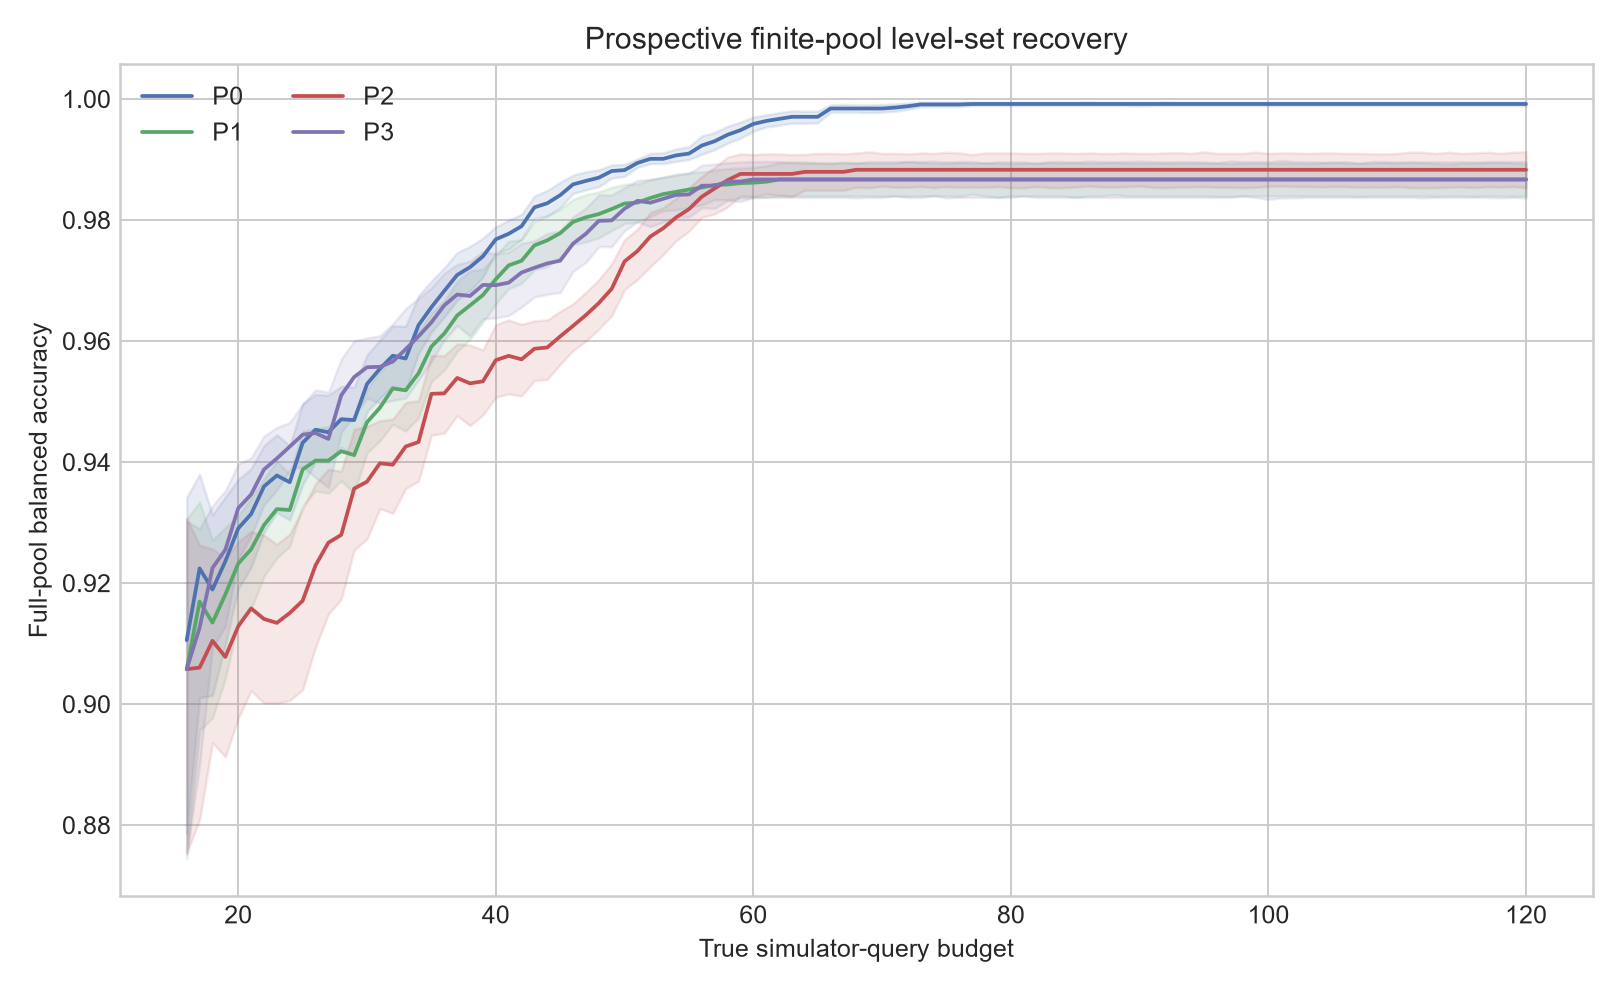

In [3]:
a=pd.read_csv(OUT/'repeat_block_aulc.csv'); display(a.groupby(['population','arm']).balanced_accuracy_AULC_16_120.agg(['mean','std']))
display(Image(filename=str(OUT/'figures/01_full_pool_learning_curves.png')))

## 3. Primary paired inference

The inferential unit is the repeat block. Holm correction covers all three monotone-vs-P0 comparisons.

,population,contrast,arm,mean_difference,ci_lower,ci_upper,raw_bootstrap_p,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws,holm_adjusted_p
0,full_405,P1_M3_MARGIN_MONO-P0,P1_M3_MARGIN_MONO,-0.009622,-0.012657,-0.006655,0.0,1,0,19,10000,0.0
1,full_405,P2_MONO_BISECTION_M3-P0,P2_MONO_BISECTION_M3,-0.013237,-0.017733,-0.008987,0.0,2,0,18,10000,0.0
2,full_405,P3_MONO_EXPECTED_GAIN_M3-P0,P3_MONO_EXPECTED_GAIN_M3,-0.008525,-0.011908,-0.005265,0.0,2,0,18,10000,0.0
3,main_364,P1_M3_MARGIN_MONO-P0,P1_M3_MARGIN_MONO,-0.011871,-0.014989,-0.008783,0.0,0,0,20,10000,0.0
4,main_364,P2_MONO_BISECTION_M3-P0,P2_MONO_BISECTION_M3,-0.014629,-0.019776,-0.009797,0.0,1,0,19,10000,0.0
5,main_364,P3_MONO_EXPECTED_GAIN_M3-P0,P3_MONO_EXPECTED_GAIN_M3,-0.011109,-0.014682,-0.007587,0.0,0,0,20,10000,0.0


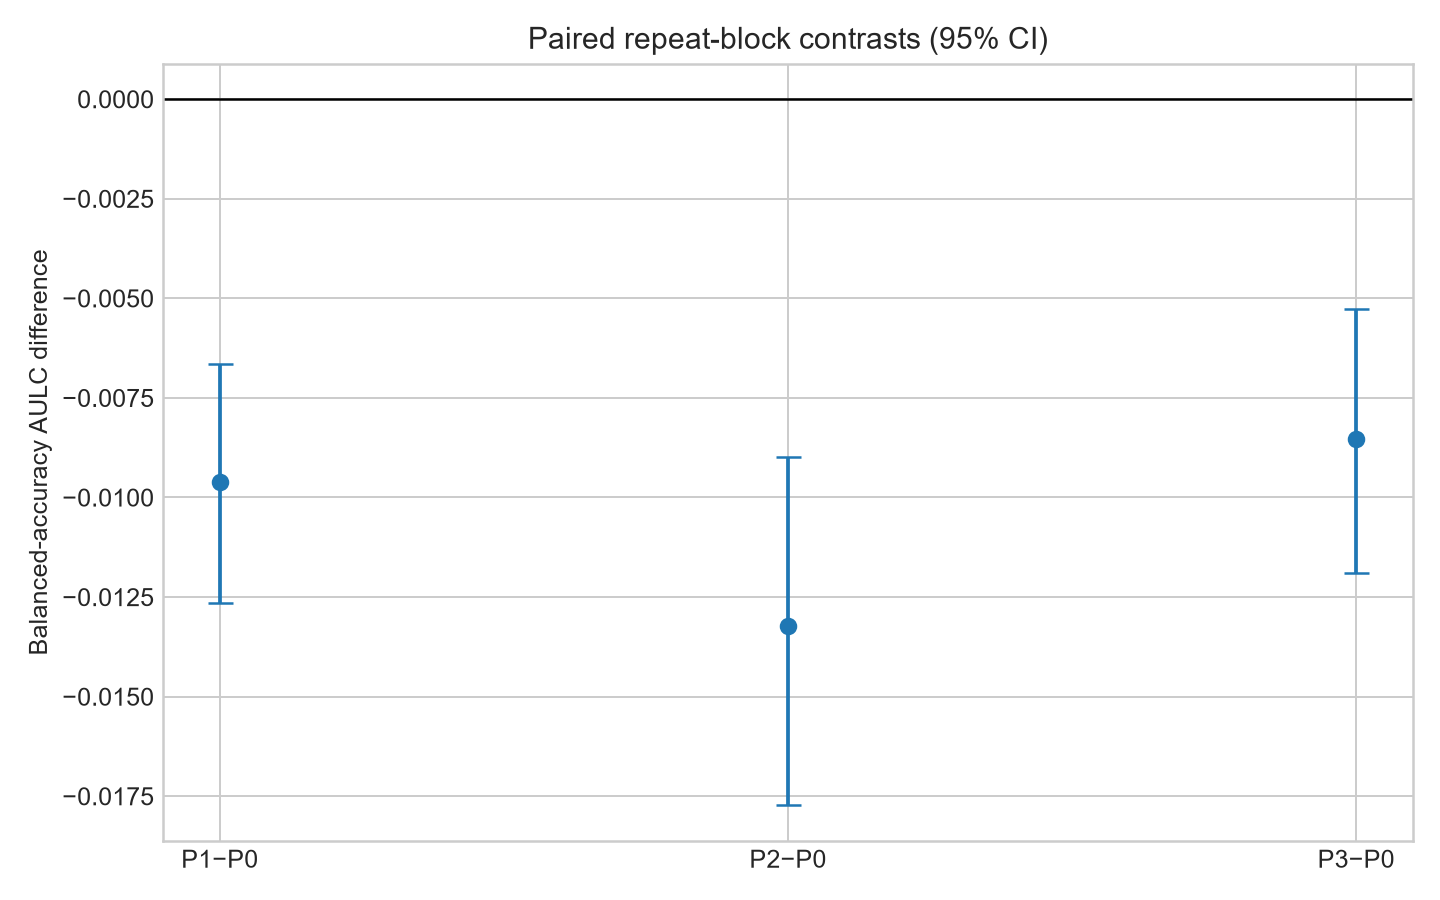

In [4]:
display(pd.read_csv(OUT/'paired_contrasts.csv'))
display(Image(filename=str(OUT/'figures/02_paired_aulc_contrasts.png')))

## 4. Structural resolution and safety

Correct resolution counts true queries and only retrospectively correct inferences. Thresholds require inferred-label error at or below 1%.

,population,arm,budget,metric,mean,ci_lower,ci_upper,maximum_repeat
45,full_405,P1_M3_MARGIN_MONO,120,inferred_N,318.500000,317.950000,319.050000,321.000000
46,full_405,P1_M3_MARGIN_MONO,120,wrong_inferred_N,2.450000,2.250000,2.650000,3.000000
47,full_405,P1_M3_MARGIN_MONO,120,wrong_inference_rate_among_inferred,0.007692,0.007058,0.008334,0.009494
48,full_405,P1_M3_MARGIN_MONO,120,wrong_inference_rate_population,0.006049,0.005556,0.006543,0.007407
49,full_405,P1_M3_MARGIN_MONO,120,wrong_inferred_KH_as_C_N,1.800000,1.350000,2.250000,3.000000
50,full_405,P1_M3_MARGIN_MONO,120,wrong_inferred_C_as_KH_N,0.650000,0.400000,0.900000,2.000000
51,full_405,P1_M3_MARGIN_MONO,120,conflicted_N,0.000000,0.000000,0.000000,0.000000
52,full_405,P1_M3_MARGIN_MONO,120,structural_coverage,1.000000,1.000000,1.000000,1.000000
53,full_405,P1_M3_MARGIN_MONO,120,correct_structural_resolution,0.993951,0.993457,0.994444,0.995062
99,full_405,P2_MONO_BISECTION_M3,120,inferred_N,312.650000,311.050000,314.300000,320.000000


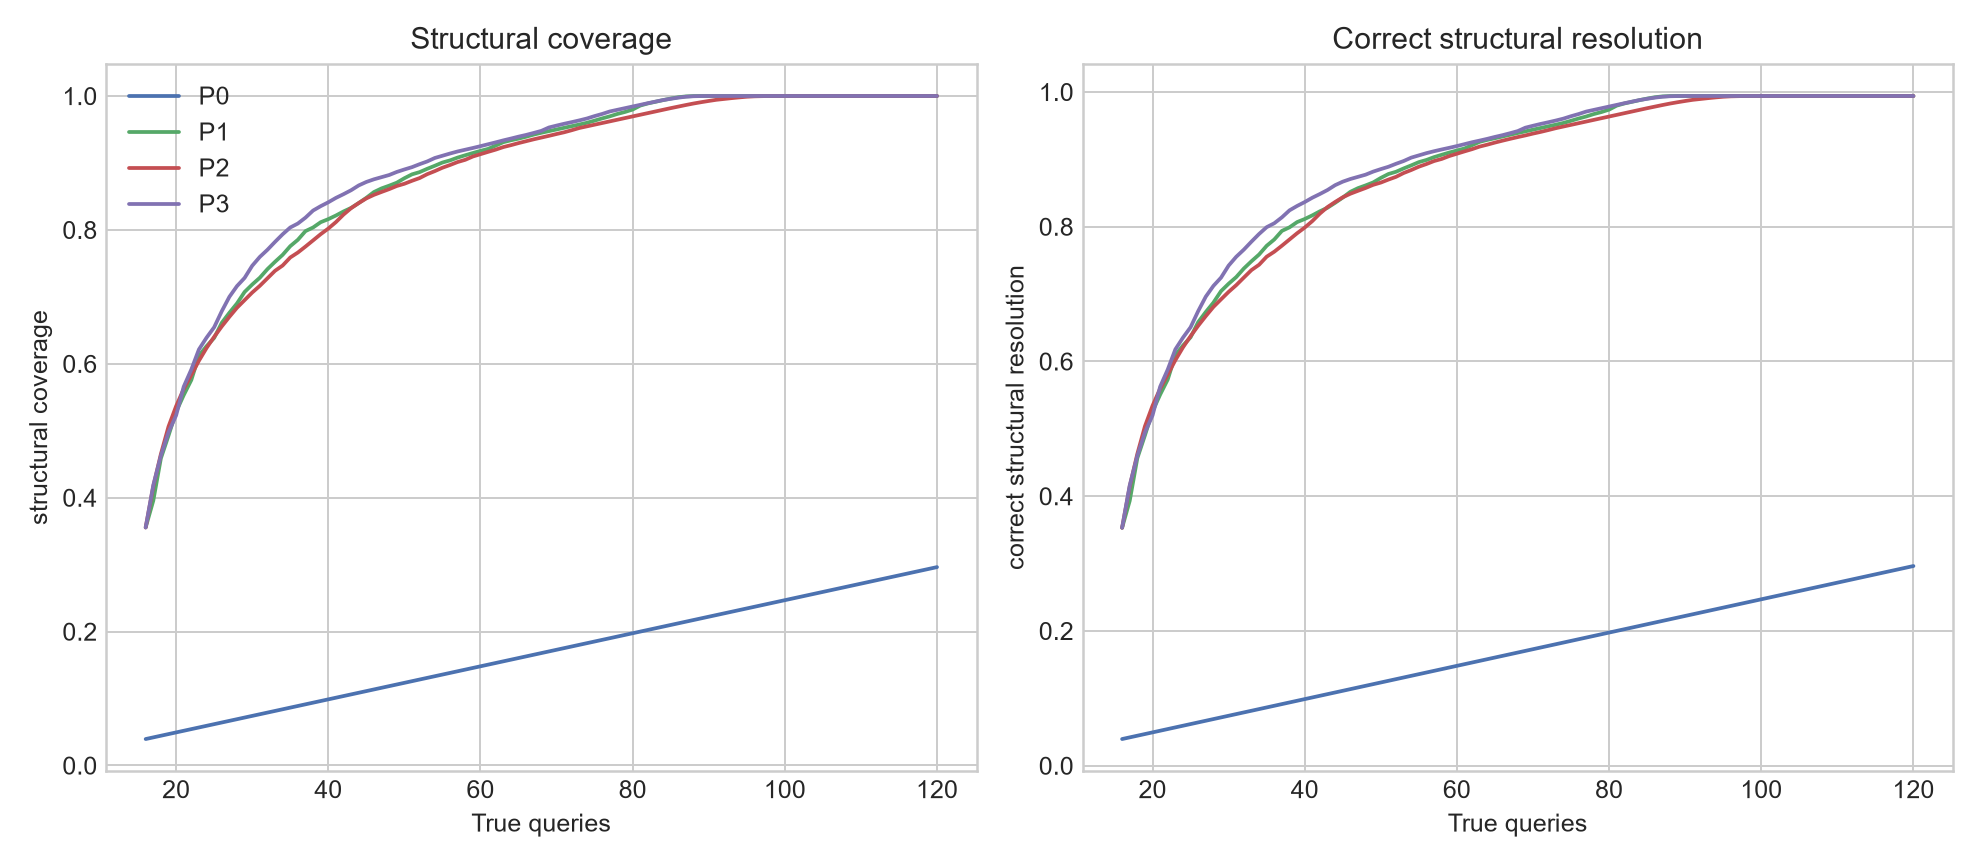

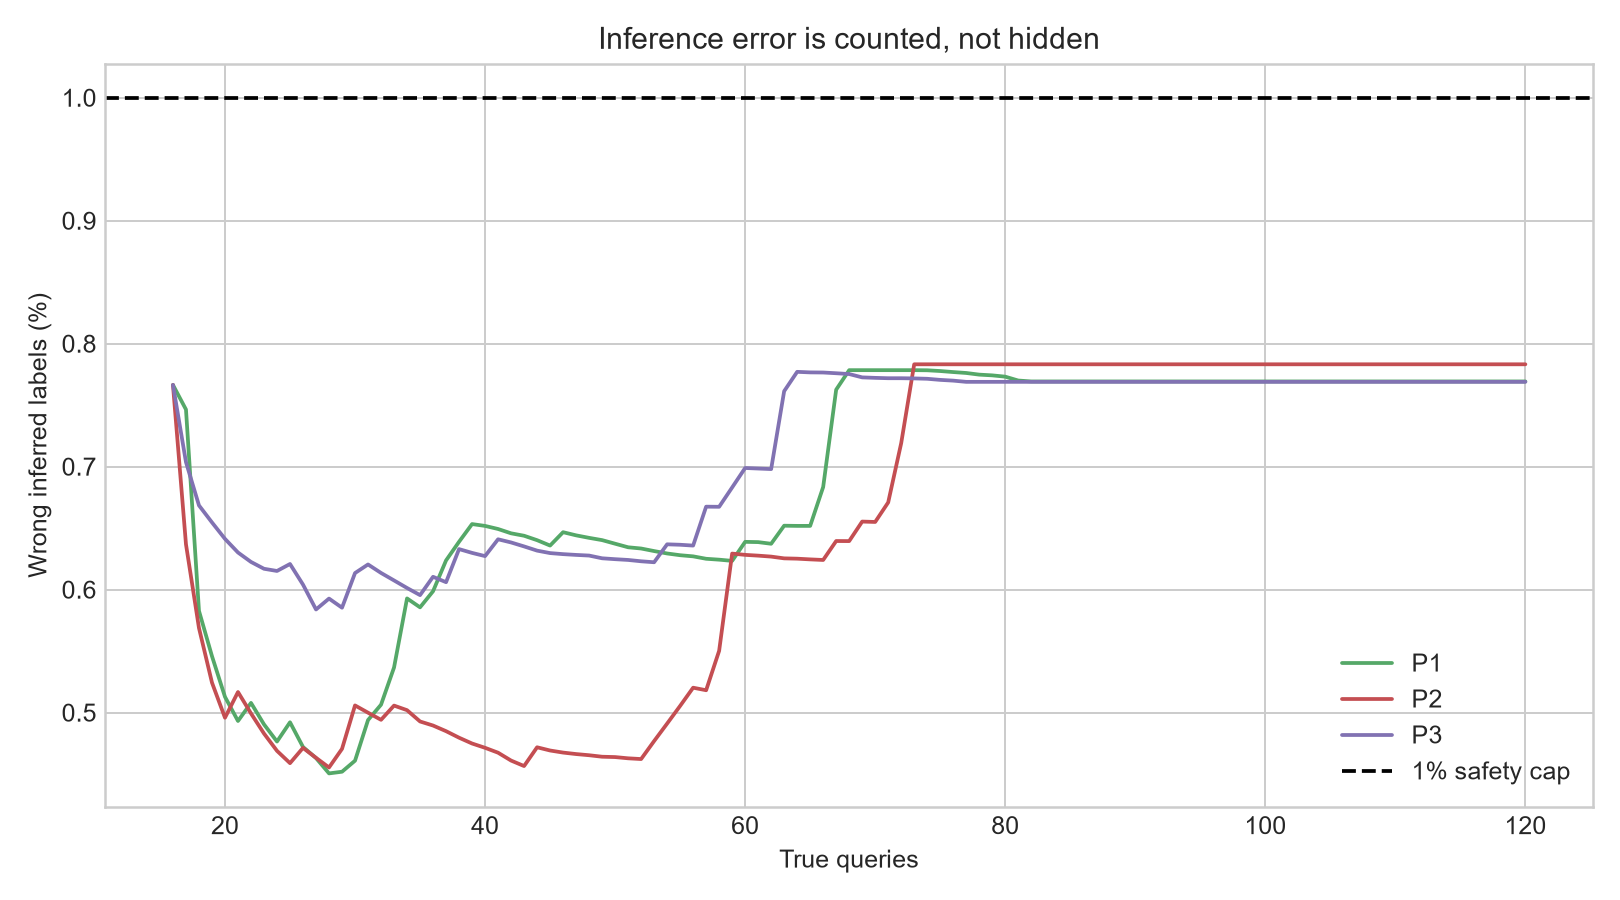

In [5]:
display(pd.read_csv(OUT/'inference_safety_summary.csv').query("budget == 120"))
display(Image(filename=str(OUT/'figures/03_structural_resolution_curves.png')))
display(Image(filename=str(OUT/'figures/05_inference_error.png')))

## 5. Query thresholds and mechanism

population  arm                       threshold
full_405    P0_M3_MARGIN_STANDARD     0.95         1.00
                                      0.97         1.00
                                      0.98         1.00
            P1_M3_MARGIN_MONO         0.95         1.00
                                      0.97         1.00
                                      0.98         0.60
            P2_MONO_BISECTION_M3      0.95         1.00
                                      0.97         1.00
                                      0.98         0.75
            P3_MONO_EXPECTED_GAIN_M3  0.95         1.00
                                      0.97         1.00
                                      0.98         0.55
main_364    P0_M3_MARGIN_STANDARD     0.95         1.00
                                      0.97         1.00
                                      0.98         1.00
            P1_M3_MARGIN_MONO         0.95         1.00
                                      0.97         1.00


population  arm                       correct_resolution_threshold
full_405    P0_M3_MARGIN_STANDARD     0.80                            0.00
                                      0.90                            0.00
                                      0.95                            0.00
            P1_M3_MARGIN_MONO         0.80                            1.00
                                      0.90                            1.00
                                      0.95                            1.00
            P2_MONO_BISECTION_M3      0.80                            1.00
                                      0.90                            1.00
                                      0.95                            1.00
            P3_MONO_EXPECTED_GAIN_M3  0.80                            1.00
                                      0.90                            1.00
                                      0.95                            1.00
main_364    P0_M3_MARGIN_STANDARD

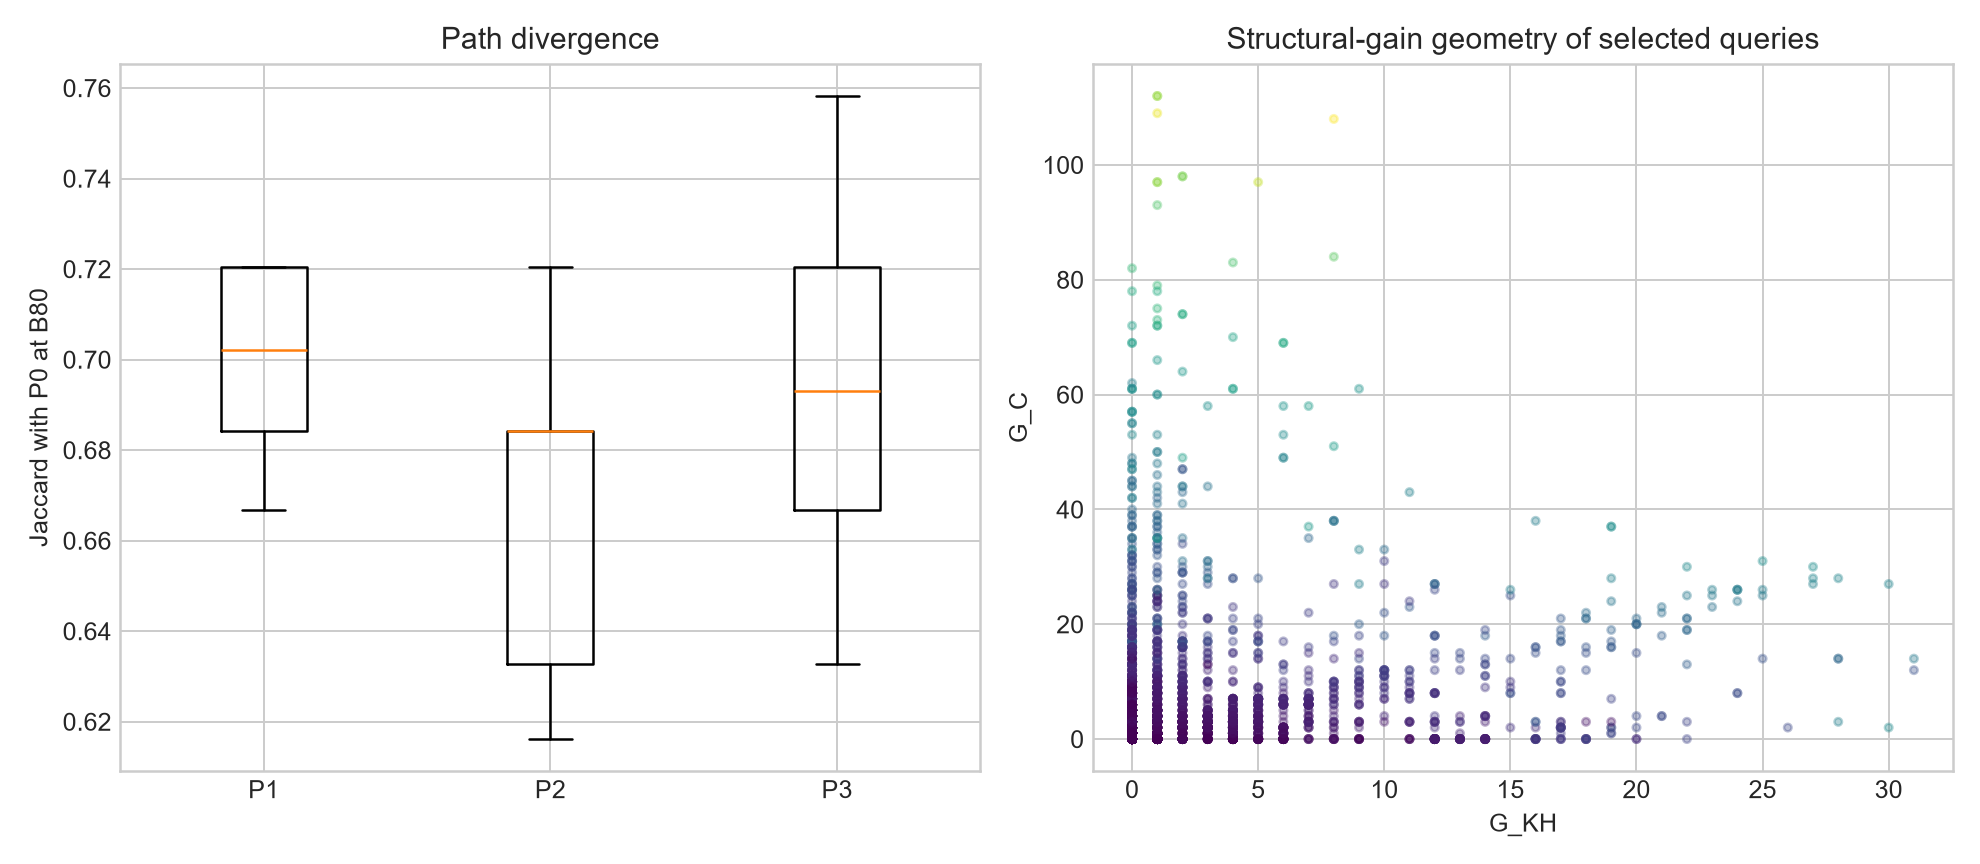

In [6]:
display(pd.read_csv(OUT/'threshold_attainment.csv').groupby(['population','arm','threshold']).reached.mean())
display(pd.read_csv(OUT/'structural_resolution_thresholds.csv').groupby(['population','arm','correct_resolution_threshold']).reached.mean())
display(Image(filename=str(OUT/'figures/06_path_implication_mechanism.png')))

## 6. Boundary diagnostics and main-configuration sensitivity

q20/q30 remain secondary and unchanged. The 364-point check reruns the same algorithms without retuning.

,record_type,arm_or_contrast,mean,ci_lower,ci_upper,no_retuning,holm_adjusted_p
0,arm_summary,P0_M3_MARGIN_STANDARD,0.988061,0.986655,0.989398,True,NaN
1,arm_summary,P1_M3_MARGIN_MONO,0.976190,0.972766,0.979622,True,NaN
2,arm_summary,P2_MONO_BISECTION_M3,0.973433,0.968511,0.978272,True,NaN
3,arm_summary,P3_MONO_EXPECTED_GAIN_M3,0.976952,0.973578,0.980235,True,NaN
4,paired_contrast,P1_M3_MARGIN_MONO-P0,-0.011871,-0.014989,-0.008783,True,0.0
5,paired_contrast,P2_MONO_BISECTION_M3-P0,-0.014629,-0.019776,-0.009797,True,0.0
6,paired_contrast,P3_MONO_EXPECTED_GAIN_M3-P0,-0.011109,-0.014682,-0.007587,True,0.0


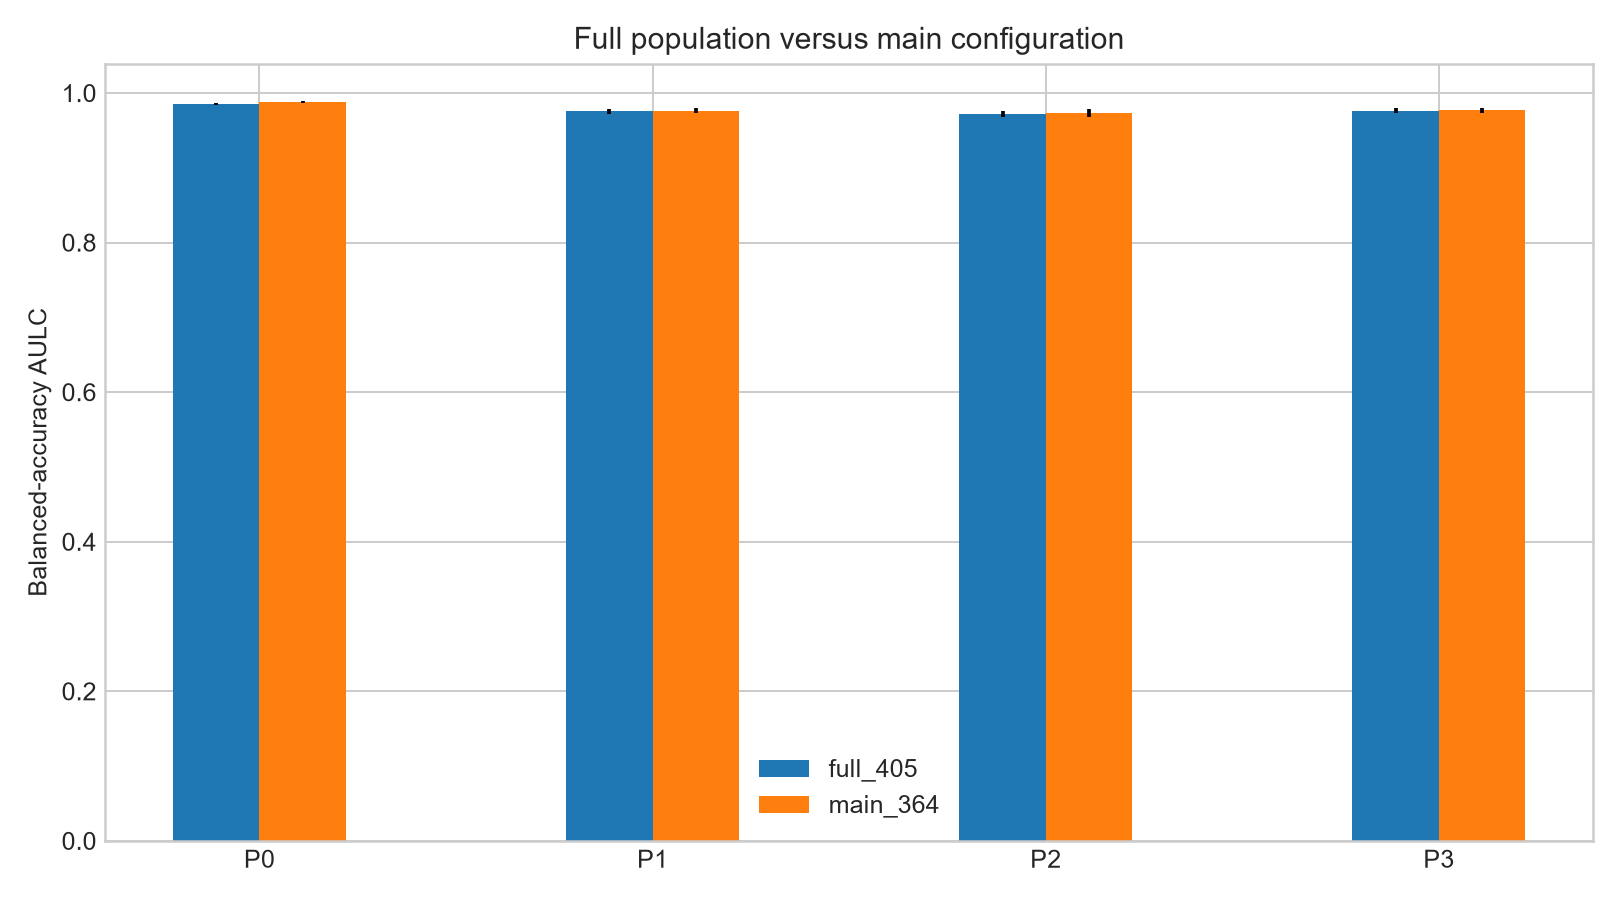

In [7]:
display(pd.read_csv(OUT/'main_configuration_sensitivity.csv'))
display(Image(filename=str(OUT/'figures/07_main_configuration_sensitivity.png')))

## 7. Decisions and claim boundary

In [8]:
for name in ['primary_decision','structural_safety_decision','label_saving_decision']:
    display({name:json.loads((OUT/f'{name}.json').read_text())})
display(Markdown((OUT/'claim_ledger.md').read_text(encoding='utf-8')))

{'primary_decision': {'P3_minus_P0_mean': -0.008524955327103928,
  'ci': [-0.011907617834681602, -0.0052645626797231115],
  'decision': 'MONOTONE_POOL_HARM',
  'holm_adjusted_p': 0.0,
  'main_config_mean': -0.011109039769754348}}

{'structural_safety_decision': {'C_as_KH_mean': 0.65,
  'KH_as_C_mean': 1.8,
  'P3_B120_mean_error_among_inferred': 0.007688910400424455,
  'ci': [0.007051130424678163, 0.008331067448987943],
  'decision': 'MONOTONE_PROPAGATION_SAFE_ENOUGH'}}

{'label_saving_decision': {'decision': 'LABEL_SAVING_NOT_SUPPORTED',
  'rule': 'paired attainment >=14/20 and 95% query-saving CI above zero',
  'supported_threshold_rows': 0}}

# Claim ledger

| Claim | Status | Evidence / limitation |
|---|---|---|
| Baseline partial order reproduces | SUPPORTED | 22,050/3 full; 19,491/3 main. |
| Inferred labels entered M3 training | FALSIFIED | Query log and engine enforce true queried labels only. |
| P3 improves finite-pool AULC over P0 | MONOTONE_POOL_HARM | Paired 20-block bootstrap and Holm family control. |
| Monotonic propagation is safe enough | MONOTONE_PROPAGATION_SAFE_ENOUGH | Incorrect inferences are explicitly counted. |
| True-query label saving is supported | LABEL_SAVING_NOT_SUPPORTED | Threshold attainment is right-censored and requires paired CI support. |
| q20 was replaced by pool-level LSE | NOT SUPPORTED | q20/q30 remain frozen secondary diagnostics. |
| Structural inferences are guaranteed labels | NOT SUPPORTED | Three frozen violations exist. |
| Continuous-domain monotonicity is established | NOT TESTED | Finite 405-point simulator pool only. |
